In [1]:
# Imports
import sys
sys.path.append('../src')

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from predict import ToxicityClassifier, LABEL_COLS

# Load classifier
classifier = ToxicityClassifier(models_dir='../models')

# Load a sample of test data for explanation
test_df = pd.read_csv('../data/test_split.csv')
sample_texts = test_df['clean_text'].sample(50, random_state=42).tolist()

c:\Users\elhay\OneDrive\Desktop\toxic-comment-classifier\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading models...
  Loaded: toxic
  Loaded: severe_toxic
  Loaded: obscene
  Loaded: threat
  Loaded: insult
  Loaded: identity_hate
All models loaded.



In [2]:
# Build a SHAP-compatible prediction function
# SHAP expects a function that takes a list of texts and returns a 2D array of probabilities for each class
# We will create a separate SHAP explainer for each label, so the prediction function will return probabilities for that specific label.

def make_predict_fn(label: str):
    """
    Create a prediction function for a specific label.
    SHAP will call this function hundreds of times (once per perturbation).
    """
    def predict_fn(texts):
        # texts is a numpy array of strings
        results = []
        for text in texts:
            probs = classifier._get_probabilities(str(text))
            # Return [prob_negative, prob_positive] — SHAP expects this format
            p_positive = probs[label]
            results.append([1 - p_positive, p_positive])
        return np.array(results)
    return predict_fn

In [ ]:
# Run SHAP TextExplainer on a few examples
# This will compute SHAP values for the 'toxic' label, showing which words contribute to a comment being classified as toxic.
# Note: SHAP can be slow, especially for text data, because it runs many perturbations of the input. Be patient!


# Analyze the 'toxic' label
label_to_explain = 'toxic'
predict_fn = make_predict_fn(label_to_explain)

# Find a toxic example to explain
toxic_examples = test_df[test_df['toxic'] == 1]['clean_text'].head(3).tolist()

explainer = shap.Explainer(
    predict_fn,
    masker=shap.maskers.Text(r"\W+"),  # mask by word boundaries
    output_names=[f'not_{label_to_explain}', label_to_explain]
)

# This can take 1-2 minutes per example — SHAP runs many perturbations
print("Computing SHAP values (this takes a few minutes)...")
shap_values = explainer(toxic_examples[:1])  # explain first example only

print("Done!")

Computing SHAP values (this takes a few minutes)...


PartitionExplainer explainer: 2it [00:23, 23.39s/it]               

Done!


In [4]:
# Visualize SHAP for a single prediction

shap.plots.text(shap_values[0, :, 1])  # index 1 = probability of 'toxic'

Computing SHAP values for 20 examples...


PartitionExplainer explainer: 4it [02:54, 58.22s/it]                       


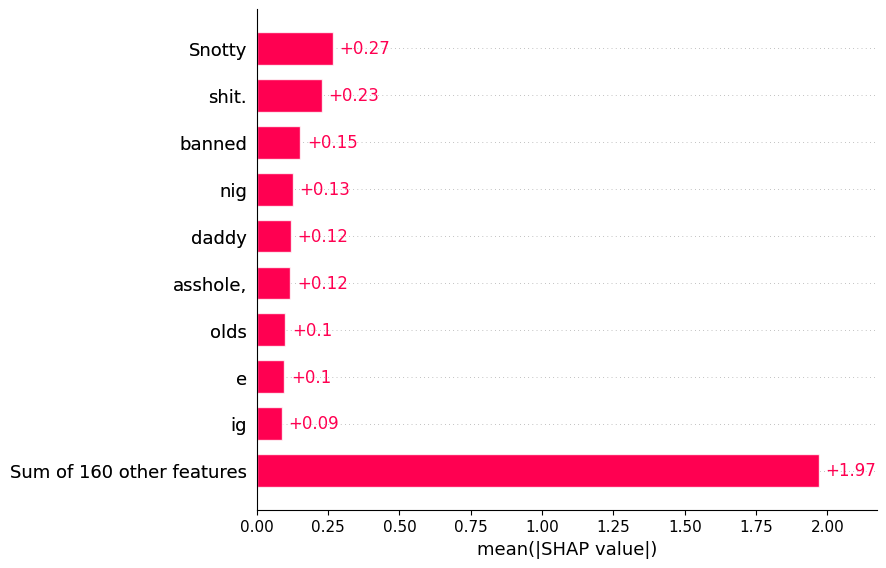

In [5]:
# SHAP summary across multiple examples 
print("Computing SHAP values for 20 examples...")
shap_values_batch = explainer(toxic_examples[:3])

# Bar plot: overall feature importance
shap.plots.bar(shap_values_batch[:, :, 1])

PartitionExplainer explainer: 2it [00:12, 12.25s/it]               


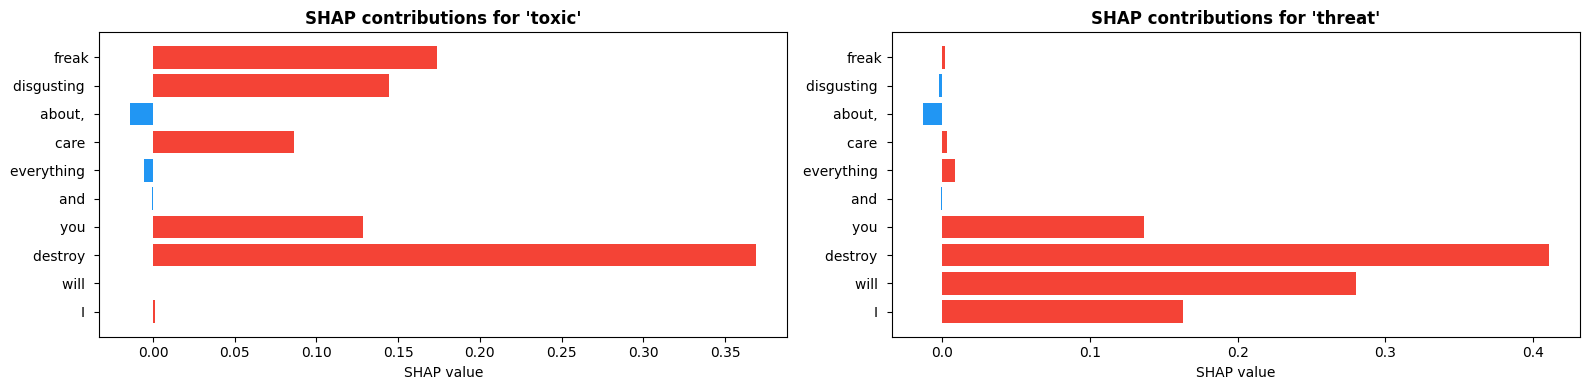

In [6]:
# Comparing SHAP across labels
# We can create separate explainers for 'toxic' and 'threat' and compare which words contribute to each label.

analysis_text = "I will destroy you and everything you care about, you disgusting freak"

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for i, label in enumerate(['toxic', 'threat']):
    predict_fn = make_predict_fn(label)
    explainer = shap.Explainer(
        predict_fn,
        masker=shap.maskers.Text(r"\W+"),
        output_names=[f'not_{label}', label]
    )
    sv = explainer([analysis_text])
    
    # Get word-level SHAP values
    words = sv.data[0]
    values = sv.values[0, :, 1]  # SHAP values for positive class
    
    colors = ['#F44336' if v > 0 else '#2196F3' for v in values]
    axes[i].barh(words, values, color=colors)
    axes[i].set_title(f"SHAP contributions for '{label}'", fontweight='bold')
    axes[i].set_xlabel('SHAP value')

plt.tight_layout()
plt.savefig('../plots/shap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()